# **Siti Naia Hesti Rachmawati | 24083010047**

In [ ]:
# Import library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# supervised learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# unsupervised learning
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PCA untuk visualisasi
from sklearn.decomposition import PCA
sns.set(style='whitegrid')

In [ ]:
# Load Iris Dataset

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
print("Jumlah data:", df.shape)
print("\nInformasi dataset:")
print(df.info())

print("\nStatistik deskriptif:")
print(df.describe())

print("\nJumlah tiap kelas:")
print(df['species'].value_counts())

Jumlah data: (150, 5)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistik deskriptif:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000        

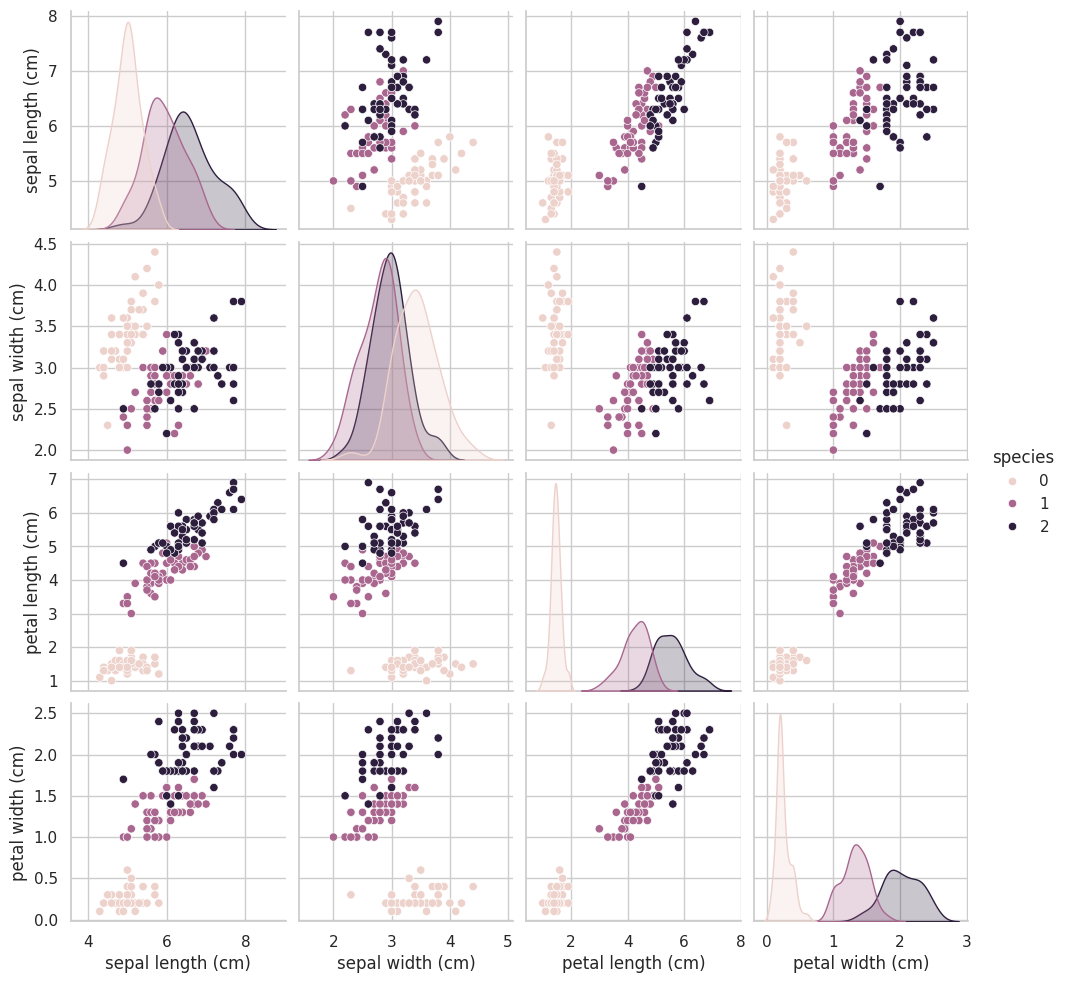

In [ ]:
# Visualisasi data

sns.pairplot(df, hue='species')
plt.show()

In [ ]:
# Split data training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (120, 4)
Testing size: (30, 4)


In [ ]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai.")

Scaling selesai.


# SUPERVISED LEARNING

In [ ]:
# @title Logistic Regression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy Logistic Regression:", acc_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy Logistic Regression: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# @title KNN dengan hyperparameter tuning

param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid_knn = GridSearchCV(knn, param_grid, cv=5)
grid_knn.fit(X_train_scaled, y_train)

print("Best parameters:", grid_knn.best_params_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy KNN terbaik:", acc_knn)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Accuracy KNN terbaik: 0.9666666666666667


In [ ]:
# @title SVM tuning

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5)
grid_svm.fit(X_train_scaled, y_train)

print("Best parameters:", grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM terbaik:", acc_svm)

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy SVM terbaik: 0.9333333333333333


In [ ]:
# @title Random Forest tuning

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest terbaik:", acc_rf)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy Random Forest terbaik: 0.9


In [ ]:
# @title Perbandingan model

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Random Forest'],
    'Accuracy': [acc_lr, acc_knn, acc_svm, acc_rf]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
1,KNN,0.966667
0,Logistic Regression,0.933333
2,SVM,0.933333
3,Random Forest,0.900000


> KNN menjadi model terbaik menunjukkan bahwa struktur data berbasis kedekatan jarak sangat kuat

> Model linear masih cukup baik yang menunjukkan data hampir linear separable

> Random forest sebenarnya masih cukup baik, namun menjadi yang terendah apabila dibandingkan dengan 3 model lainnya, ini dikarenakan data iris tidak cukup kompleks untuk dimodelkan menggunakan random forest



> Berdasarkan hasil implementasi supervised learning, model K-Nearest Neighbors memberikan performa terbaik dengan akurasi sebesar 96.67%, diikuti oleh Logistic Regression dan Support Vector Machine sebesar 93.33%, serta Random Forest sebesar 90%.

> Hal ini menunjukkan bahwa struktur dataset Iris memiliki karakteristik berbasis kedekatan jarak yang kuat, sehingga model berbasis distance seperti KNN mampu mengklasifikasikan data dengan lebih akurat.

> Selain itu, tingginya akurasi pada semua model menunjukkan bahwa dataset memiliki separabilitas yang baik dan feature yang digunakan memiliki kemampuan diskriminatif yang tinggi.


> Perbedaan performa antar model juga menunjukkan bahwa kompleksitas dataset relatif rendah hingga menengah, dimana model sederhana sudah mampu memberikan hasil yang sangat baik.

# UNSUPERVISED LEARNING

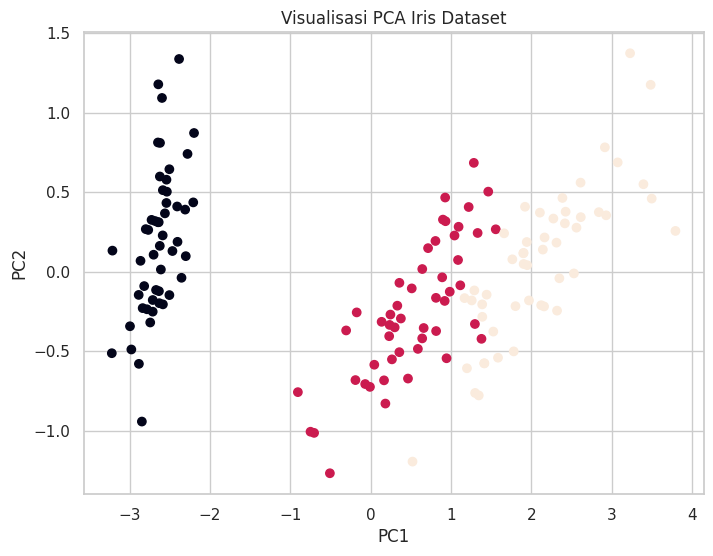

In [ ]:
# @title PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

plt.title("Visualisasi PCA Iris Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
# @title KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

print("Cluster labels:")
print(clusters[:10])

Cluster labels:
[1 1 1 1 1 1 1 1 1 1]


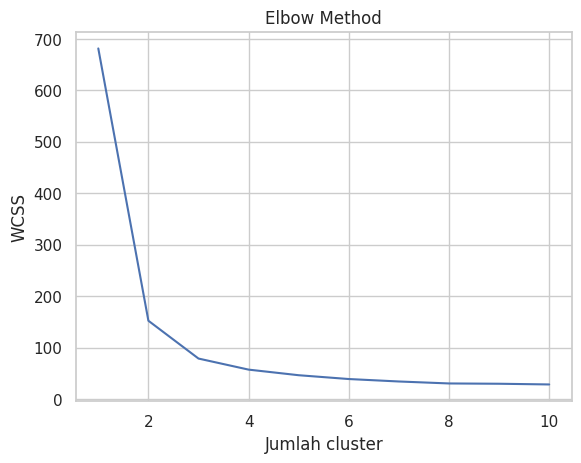

In [ ]:
# @title Elbow method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")
plt.xlabel("Jumlah cluster")
plt.ylabel("WCSS")

plt.show()

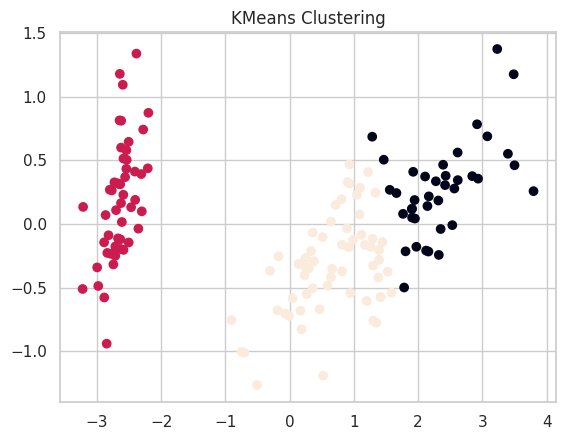

In [ ]:
# Visualisasi cluster

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("KMeans Clustering")

plt.show()

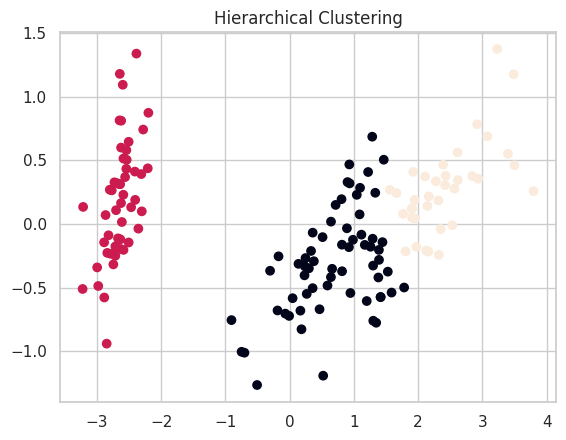

In [ ]:
# Hierarchical clustering

hc = AgglomerativeClustering(n_clusters=3)

hc_clusters = hc.fit_predict(X)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_clusters
)

plt.title("Hierarchical Clustering")

plt.show()

> Berdasarkan hasil implementasi metode unsupervised learning pada dataset Iris, diperoleh bahwa struktur data secara intrinsik membentuk 3 kelompok utama yang sesuai dengan jumlah spesies bunga iris.

> Hal ini dibuktikan melalui Elbow Method, dimana nilai Within-Cluster Sum of Squares (WCSS) mengalami penurunan signifikan hingga jumlah cluster sebanyak 3, kemudian melandai pada jumlah cluster berikutnya. Kondisi ini menunjukkan bahwa 3 cluster merupakan jumlah optimal yang mampu merepresentasikan struktur alami data secara efisien tanpa menimbulkan over-segmentation.

> Hasil clustering menggunakan algoritma K-Means menunjukkan bahwa sebagian besar data berhasil dikelompokkan ke dalam cluster yang homogen berdasarkan kemiripan karakteristik morfologinya.

> Visualisasi menggunakan Principal Component Analysis (PCA) memperlihatkan bahwa cluster yang terbentuk memiliki separasi yang cukup jelas, terutama pada spesies Setosa yang membentuk cluster terpisah secara signifikan dari dua spesies lainnya. Hal ini menggambarkan bahwa spesies Setosa memiliki karakteristik morfologi yang paling berbeda dibandingkan Versicolor dan Virginica. Sementara itu, terdapat sedikit kedekatan antara cluster Versicolor dan Virginica, yang menunjukkan adanya kemiripan karakteristik di antara kedua spesies tersebut.

> Selain itu, hasil Hierarchical Clustering juga menunjukkan pola pengelompokan yang konsisten dengan hasil K-Means, dimana data secara bertahap dikelompokkan berdasarkan tingkat kemiripan fitur.

> Konsistensi hasil antara kedua metode clustering ini menunjukkan bahwa distribusi data memiliki struktur cluster yang stabil dan tidak terbentuk secara acak.

> Secara keseluruhan, hasil unsupervised learning menunjukkan bahwa dataset Iris memiliki struktur internal yang jelas dan terorganisir dengan baik, dimana data secara alami membentuk kelompok-kelompok yang sesuai dengan spesies biologisnya.

> Hal ini menunjukkan bahwa fitur-fitur yang digunakan, khususnya petal length dan petal width, memiliki kemampuan yang kuat dalam merepresentasikan perbedaan karakteristik antar spesies. Dengan demikian, metode unsupervised learning terbukti efektif dalam mengidentifikasi pola dan struktur tersembunyi dalam dataset tanpa menggunakan informasi label, serta mampu mengungkap kesamaan dan perbedaan karakteristik antar kelompok secara objektif berdasarkan distribusi data.